In [40]:
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt

# ====================================================
# 1. Global config
# ====================================================
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 1337

root_dir = Path("/data/classes/2025/fall/cs426/bartlecg5526/group_2/chest_xray")
train_dir = root_dir / "train"           # NORMAL / PNEUMONIA(/bacteria,virus)
test_dir  = root_dir / "test"            # NORMAL / PNEUMONIA(/bacteria,virus)
train_pneu_dir = train_dir / "PNEUMONIA" # bacteria / virus
test_pneu_dir  = test_dir / "PNEUMONIA"  # bacteria / virus

AUTOTUNE = tf.data.AUTOTUNE

In [41]:
# ====================================================
# 2. Preprocess + prepare helper
# ====================================================
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def prepare(ds, shuffle=False, repeat=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    if repeat:
        ds = ds.repeat()
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds



In [42]:
# ====================================================
# 3. Task A1: NORMAL vs PNEUMONIA
#    - use train/ (NORMAL, PNEUMONIA)
#    - test/ as fixed test set
#    - 10% of train used as validation
# ====================================================
# Load full training (unbatched) and test
train_full_A1 = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
    batch_size=None,
)

test_raw_A1 = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    seed=SEED,
    batch_size=None,
)

print("A1 classes:", train_full_A1.class_names)  # ['NORMAL', 'PNEUMONIA']

total_train_A1 = train_full_A1.cardinality().numpy()
val_size_A1 = int(0.10 * total_train_A1)
train_size_A1 = total_train_A1 - val_size_A1

train_raw_A1 = train_full_A1.take(train_size_A1)
val_raw_A1   = train_full_A1.skip(train_size_A1)

# --- A1 subsets ---
total_train_A1 = train_raw_A1.cardinality().numpy()

def make_A1_subset(fraction):
    n = int(total_train_A1 * fraction)
    subset_raw = train_raw_A1.take(n)
    return prepare(subset_raw, shuffle=True)

train_A1_10  = make_A1_subset(0.10)
train_A1_25  = make_A1_subset(0.25)
train_A1_50  = make_A1_subset(0.50)
train_A1_100 = prepare(train_raw_A1, shuffle=True)  # full pool

val_A1 = prepare(val_raw_A1)
test_A1 = prepare(test_raw_A1)



Found 5232 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
A1 classes: ['NORMAL', 'PNEUMONIA']


In [43]:
# ====================================================
# 4. Task A2: BACTERIA vs VIRUS (pneumonia only)
#    - use train/PNEUMONIA (bacteria, virus)
#    - test/PNEUMONIA as fixed test
#    - 10% of pneumonia-train used as validation
# ====================================================
train_full_A2 = tf.keras.utils.image_dataset_from_directory(
    train_pneu_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
    batch_size=None,
)

test_raw_A2 = tf.keras.utils.image_dataset_from_directory(
    test_pneu_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    seed=SEED,
    batch_size=None,
)

print("A2 classes:", train_full_A2.class_names)  # ['bacteria', 'virus']

total_train_A2 = train_full_A2.cardinality().numpy()
val_size_A2 = int(0.10 * total_train_A2)
train_size_A2 = total_train_A2 - val_size_A2

train_raw_A2 = train_full_A2.take(train_size_A2)
val_raw_A2   = train_full_A2.skip(train_size_A2)

# --- A2 subsets ---
total_train_A2 = train_raw_A2.cardinality().numpy()

def make_A2_subset(fraction):
    n = int(total_train_A2 * fraction)
    subset_raw = train_raw_A2.take(n)
    return prepare(subset_raw, shuffle=True)

train_A2_10  = make_A2_subset(0.10)
train_A2_25  = make_A2_subset(0.25)
train_A2_50  = make_A2_subset(0.50)
train_A2_100 = prepare(train_raw_A2, shuffle=True)

val_A2 = prepare(val_raw_A2, repeat=True)
test_A2 = prepare(test_raw_A2)

val_steps_A2 = max(1, val_raw_A2.cardinality().numpy() // BATCH_SIZE)




Found 3883 files belonging to 2 classes.
Found 390 files belonging to 2 classes.
A2 classes: ['bacteria', 'virus']


In [44]:
# ====================================================
# 5. Shared model definition: MobileNetV2 from scratch
# ====================================================
def make_backbone():
    return tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights=None,      # from scratch
        pooling='avg'
    )

def make_classifier(num_classes):
    backbone = make_backbone()
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = backbone(inputs, training=True)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model



In [45]:
from collections import OrderedDict

# ====================================================
# 6. Train Model A1 (NORMAL vs PNEUMONIA)
# ====================================================
EPOCHS = 20
a1_subsets = {
    "10%": train_A1_10,
    "25%": train_A1_25,
    "50%": train_A1_50,
    "100%": train_A1_100,
}

histories_A1 = {}
tests_A1 = {}
models_A1 = OrderedDict()  

for name, train_ds in a1_subsets.items():
    print(f"\n=== A1 training on {name} of pool ===")
    model = make_classifier(num_classes=2)
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_A1,
    )
    histories_A1[name] = history.history
    tests_A1[name] = model.evaluate(test_A1, return_dict=True)
    models_A1[name] = model             # <--- keep trained model

print("A1 test metrics per subset:", tests_A1)






=== A1 training on 10% of pool ===
Epoch 1/20
15/15 [==============================] - 30s 706ms/step - loss: 0.4456 - accuracy: 0.8340 - val_loss: 0.3023 - val_accuracy: 0.8662
Epoch 2/20
15/15 [==============================] - 12s 668ms/step - loss: 0.3310 - accuracy: 0.8340 - val_loss: 0.2430 - val_accuracy: 0.8872
Epoch 3/20
15/15 [==============================] - 12s 674ms/step - loss: 0.2449 - accuracy: 0.8851 - val_loss: 0.3390 - val_accuracy: 0.8298
Epoch 4/20
15/15 [==============================] - 12s 667ms/step - loss: 0.2229 - accuracy: 0.9000 - val_loss: 0.2488 - val_accuracy: 0.8987
Epoch 5/20
15/15 [==============================] - 12s 666ms/step - loss: 0.1573 - accuracy: 0.9319 - val_loss: 0.2341 - val_accuracy: 0.9082
Epoch 6/20
15/15 [==============================] - 12s 670ms/step - loss: 0.1534 - accuracy: 0.9319 - val_loss: 0.2109 - val_accuracy: 0.9159
Epoch 7/20
15/15 [==============================] - 12s 670ms/step - loss: 0.1369 - accuracy: 0.9489 - val

In [46]:
# ====================================================
# 7. Train Model A2 (BACTERIA vs VIRUS)
# ====================================================
a2_subsets = {
    "10%": train_A2_10,
    "25%": train_A2_25,
    "50%": train_A2_50,
    "100%": train_A2_100,
}

histories_A2 = {}
tests_A2 = {}
models_A2 = OrderedDict() 

for name, train_ds in a2_subsets.items():
    print(f"\n=== A2 training on {name} of pool ===")
    model = make_classifier(num_classes=2)
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_A2,
        validation_steps=val_steps_A2,
    )
    histories_A2[name] = history.history
    tests_A2[name] = model.evaluate(test_A2, return_dict=True)
    models_A2[name] = model          

print("A2 test metrics per subset:", tests_A2)


=== A2 training on 10% of pool ===
Epoch 1/20
11/11 [==============================] - 22s 480ms/step - loss: 0.8377 - accuracy: 0.5903 - val_loss: 0.8670 - val_accuracy: 0.5885
Epoch 2/20
11/11 [==============================] - 5s 411ms/step - loss: 0.7661 - accuracy: 0.6189 - val_loss: 0.6337 - val_accuracy: 0.6536
Epoch 3/20
11/11 [==============================] - 5s 411ms/step - loss: 0.6862 - accuracy: 0.6590 - val_loss: 0.7409 - val_accuracy: 0.6094
Epoch 4/20
11/11 [==============================] - 5s 413ms/step - loss: 0.6732 - accuracy: 0.6504 - val_loss: 0.7442 - val_accuracy: 0.6406
Epoch 5/20
11/11 [==============================] - 6s 449ms/step - loss: 0.6675 - accuracy: 0.7020 - val_loss: 0.5456 - val_accuracy: 0.7526
Epoch 6/20
11/11 [==============================] - 5s 412ms/step - loss: 0.5771 - accuracy: 0.7049 - val_loss: 0.5729 - val_accuracy: 0.7214
Epoch 7/20
11/11 [==============================] - 6s 435ms/step - loss: 0.5373 - accuracy: 0.7622 - val_loss:

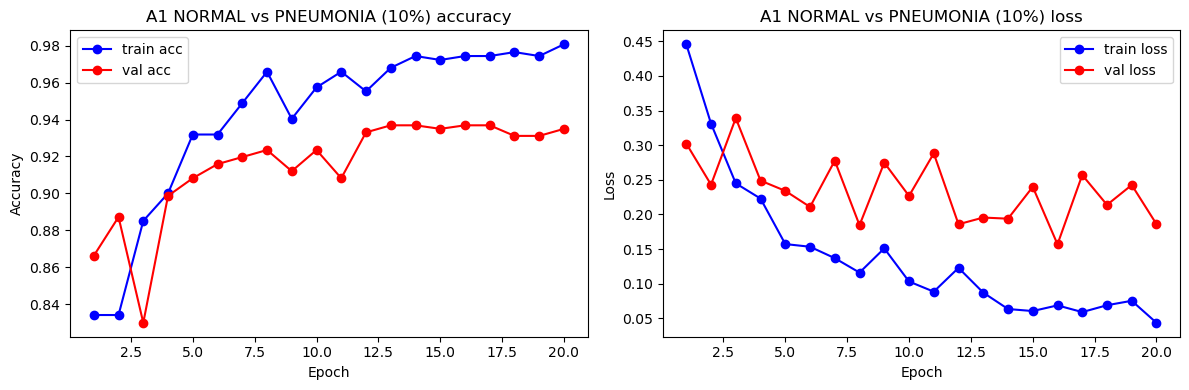

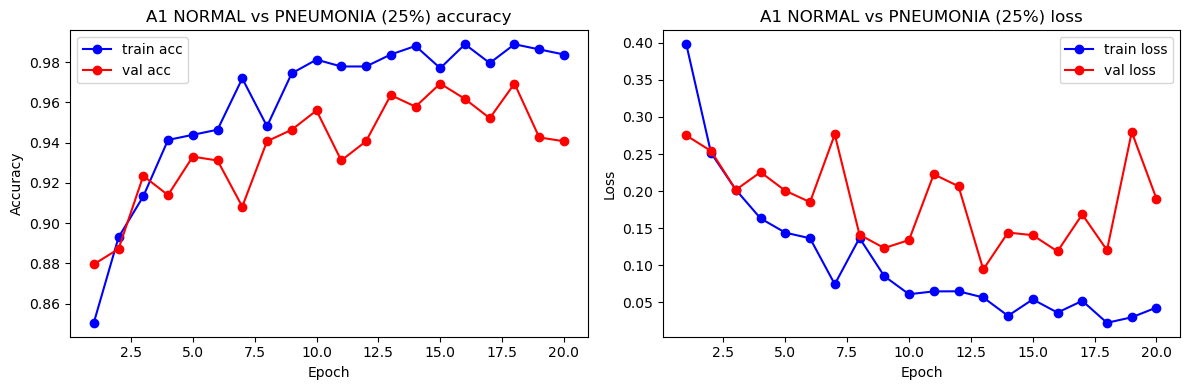

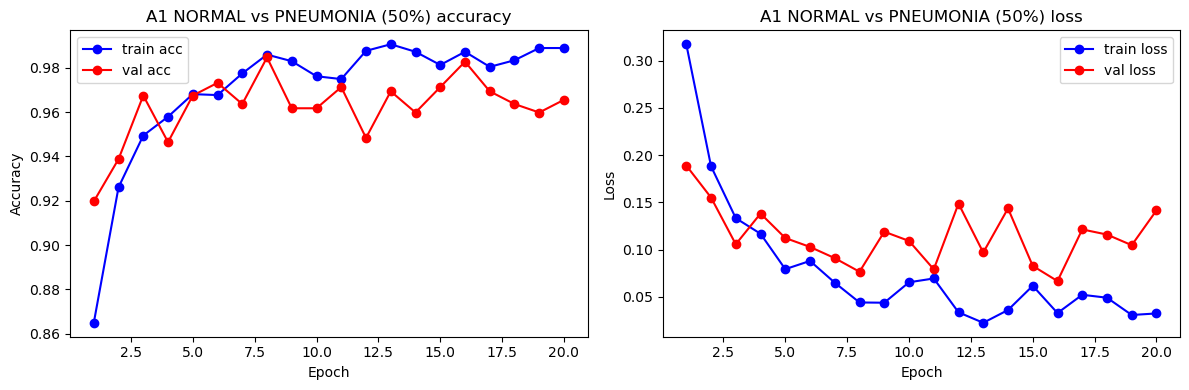

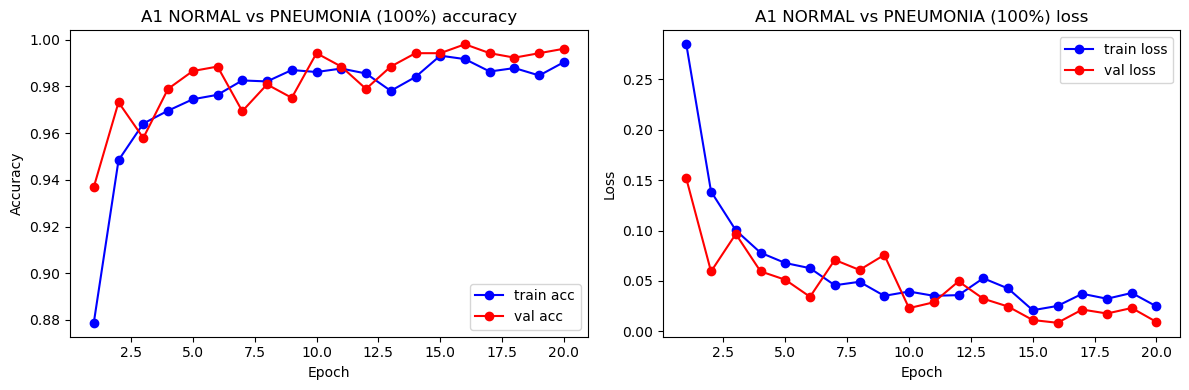

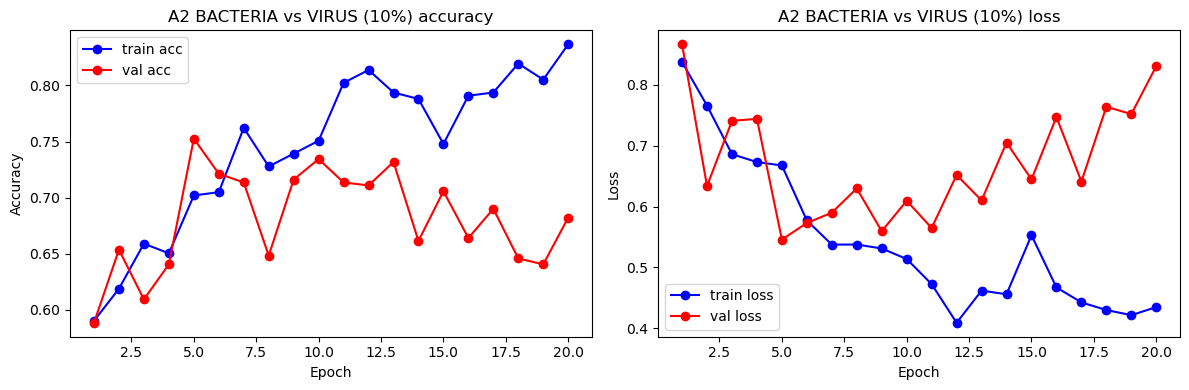

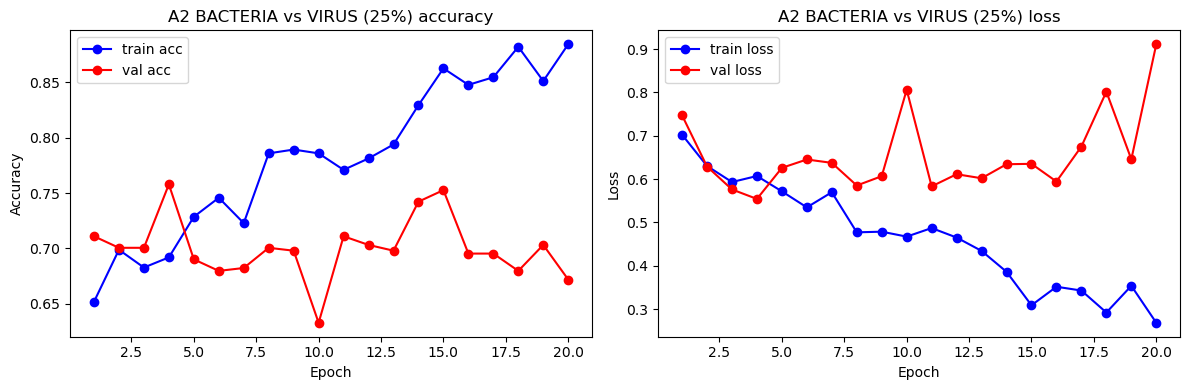

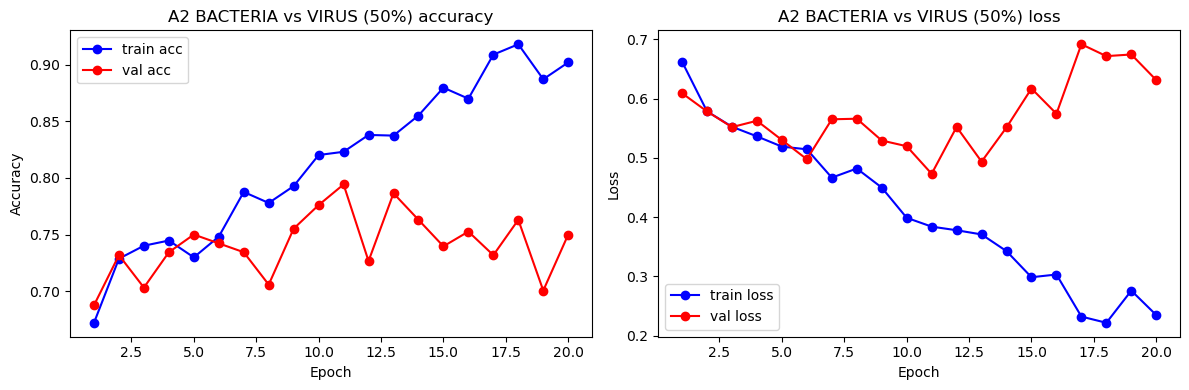

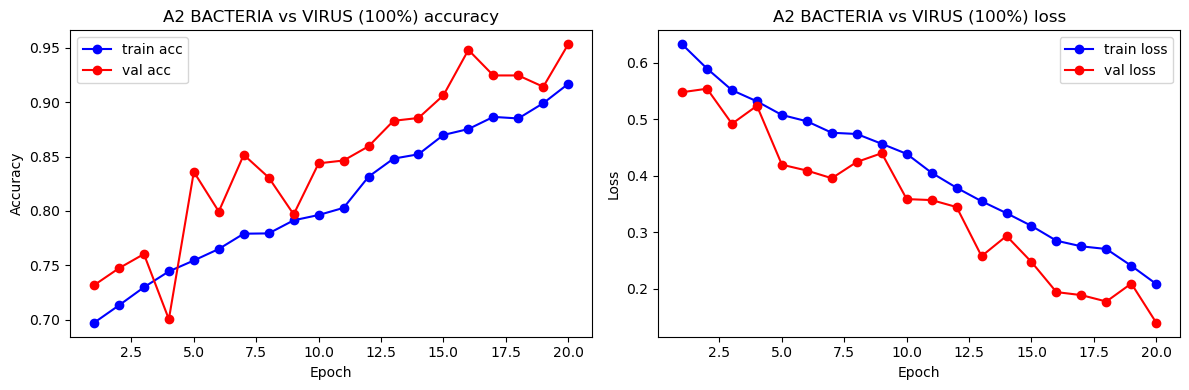

In [47]:
# ====================================================
# Plot histories for all subsets
# ====================================================

class HistoryWrapper:
    def __init__(self, hist_dict):
        self.history = hist_dict

# existing plotting function (unchanged)
def plot_history(history, title_prefix="Model"):
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])

    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    if acc:
        epochs_acc = range(1, len(acc) + 1)
        plt.plot(epochs_acc, acc, "bo-", label="train acc")
    if val_acc:
        epochs_val_acc = range(1, len(val_acc) + 1)
        plt.plot(epochs_val_acc, val_acc, "ro-", label="val acc")
    plt.title(f"{title_prefix} accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    if loss:
        epochs_loss = range(1, len(loss) + 1)
        plt.plot(epochs_loss, loss, "bo-", label="train loss")
    if val_loss:
        epochs_val_loss = range(1, len(val_loss) + 1)
        plt.plot(epochs_val_loss, val_loss, "ro-", label="val loss")
    plt.title(f"{title_prefix} loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

# plot all A1 subset runs
for frac, hist_dict in histories_A1.items():
    plot_history(HistoryWrapper(hist_dict),
                 title_prefix=f"A1 NORMAL vs PNEUMONIA ({frac})")

# plot all A2 subset runs
for frac, hist_dict in histories_A2.items():
    plot_history(HistoryWrapper(hist_dict),
                 title_prefix=f"A2 BACTERIA vs VIRUS ({frac})")


In [48]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

def eval_with_confusion(model, test_ds, class_names, title="Model"):
    y_true = []
    y_pred = []

    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        preds_labels = np.argmax(preds, axis=1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds_labels)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    print(f"\n{title} - Confusion matrix")
    print(cm)

    print(f"\n{title} - Classification report")
    print(classification_report(y_true, y_pred, target_names=class_names))


In [49]:
class_names_A1 = ["NORMAL", "PNEUMONIA"]
class_names_A2 = ["BACTERIA", "VIRUS"]

# A1: NORMAL vs PNEUMONIA
for name, model in models_A1.items():
    eval_with_confusion(
        model,
        test_A1,
        class_names_A1,
        title=f"A1 ({name} train pool)"
    )

# A2: BACTERIA vs VIRUS
for name, model in models_A2.items():
    eval_with_confusion(
        model,
        test_A2,
        class_names_A2,
        title=f"A2 ({name} train pool)"
    )



A1 (10% train pool) - Confusion matrix
[[ 54 180]
 [ 61 329]]

A1 (10% train pool) - Classification report
              precision    recall  f1-score   support

      NORMAL       0.47      0.23      0.31       234
   PNEUMONIA       0.65      0.84      0.73       390

    accuracy                           0.61       624
   macro avg       0.56      0.54      0.52       624
weighted avg       0.58      0.61      0.57       624


A1 (25% train pool) - Confusion matrix
[[ 59 175]
 [ 43 347]]

A1 (25% train pool) - Classification report
              precision    recall  f1-score   support

      NORMAL       0.58      0.25      0.35       234
   PNEUMONIA       0.66      0.89      0.76       390

    accuracy                           0.65       624
   macro avg       0.62      0.57      0.56       624
weighted avg       0.63      0.65      0.61       624


A1 (50% train pool) - Confusion matrix
[[ 72 162]
 [ 70 320]]

A1 (50% train pool) - Classification report
              precisio